<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/spat_protein.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Block 1: Global Styling & Setup
Imports the required data science packages and sets the visual fingerprint (fonts, colors, and line weights) so the final plot perfectly matches previous  figures.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 20,      # Global title padding
    "axes.labelsize": 12,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2,
    "svg.fonttype": "none" # Protects text vectors for journal export
})
sns.set_theme(style="white", font="serif")

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}

sub_condition_plot_order = [
    'Ambient \n(23°C, pH 8.2, 10m)',
    '27°C',
    '32°C',
    'pH 7.8',
    'pH 7.6',
    '50m',
    'Dark',
]

global_fig_size = (10, 6)
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling (with bold asterisks and reduced Y-ticks) initialized.")


Global styling (with bold asterisks and reduced Y-ticks) initialized.


# Block 2: Data Upload & Cleaning
Loads both CSV files and standardizes the column names. It corrects the "Treratment" typo in your protein file and ensures the light depths are formatted as clean strings so they can be matched.

In [31]:
# Load the datasets
df_oxy = pd.read_csv('TotalSpatsOxy.csv')
df_prot = pd.read_csv('ProteinSumUp.csv')

# Clean columns in Oxygen dataset
df_oxy.columns = df_oxy.columns.str.strip()
df_oxy['LightDepth'] = df_oxy['LightDepth'].astype(str).str.strip().str.lower()
df_oxy['morph'] = df_oxy['morph'].astype(str).str.strip()

# Clean columns in Protein dataset
df_prot.columns = df_prot.columns.str.strip()
if 'Treratment' in df_prot.columns:
    df_prot = df_prot.rename(columns={'Treratment': 'Treatment'})
df_prot['Treatment'] = df_prot['Treatment'].astype(str).str.strip()
df_prot['morph'] = df_prot['morph'].astype(str).str.strip()

# --- FIX NAMING MISMATCHES ---
# Standardize names and combine 'control' into 'Ambient'
name_fixes = {
    'control': 'Ambient',
    '27c': '27°C',
    '32c': '32°C',
    '7.8': 'pH 7.8',
    '7.6': 'pH 7.6',
    '8.2': 'Ambient',
    'DARK': 'Dark'
}
df_prot['Treatment'] = df_prot['Treatment'].replace(name_fixes)

# Filter only HF and NF morphs
df_oxy = df_oxy[df_oxy['morph'].isin(['HF', 'NF'])]
df_prot = df_prot[df_prot['morph'].isin(['HF', 'NF'])]

print(f"✅ Block 2 Updated: 'control' combined with 'Ambient'. Total protein records: {len(df_prot)}.")

✅ Block 2 Updated: 'control' combined with 'Ambient'. Total protein records: 84.


# Block 3: Extract Average Area per Treatment & Morph
Uses the specific physiological parameters you provided to filter the TotalSpatsOxy dataset, calculate the average spat area ($mm^2$) for HF and NF morphs under each condition, and saves it into a reference dictionary.

In [32]:
# Define the environmental conditions for each treatment name
treatment_conditions = {
    'control': (23, 8.2, '10m'),
    'Ambient': (23, 8.2, '10m'),
    '27°C':    (27, 8.2, '10m'),
    '32°C':    (32, 8.2, '10m'),
    'pH 7.8':  (23, 7.8, '10m'),
    'pH 7.6':  (23, 7.6, '10m'),
    '50m':     (23, 8.2, '50m'),
    'Dark':    (23, 8.2, 'dark')
}

area_map = {}
for treatment, (temp, ph, light) in treatment_conditions.items():
    subset = df_oxy[(df_oxy['temp'] == temp) & (df_oxy['pH'] == ph) & (df_oxy['LightDepth'] == light)]
    if not subset.empty:
        mean_areas = subset.groupby('morph')['area mm^2'].mean().to_dict()
        area_map[treatment] = mean_areas

print("✅ Block 3 Re-executed: Average Areas Updated.")

✅ Block 3 Re-executed: Average Areas Updated.


# Block 4: Map Areas and Calculate Protein Density
Looks at every row in  protein file, finds the matching average area from the dictionary we built in Block 3, assigns it to a new column, and calculates the true protein density (ug/mm2).

In [47]:
def assign_area(row):
    treat = row['Treatment']
    morph = row['morph']
    if treat in area_map and morph in area_map[treat]:
        return area_map[treat][morph]
    return np.nan

# Map areas and calculate density
df_prot['Dynamic_Area_mm2'] = df_prot.apply(assign_area, axis=1)
df_prot['prot_ug_mm2_calculated'] = df_prot['con per spat ug/ml'] / df_prot['Dynamic_Area_mm2']

# Prepare dataset - No filtering applied
df_clean = df_prot.dropna(subset=['prot_ug_mm2_calculated', 'Treatment', 'morph']).copy()

print(f"✅ Block 4 Updated: Outlier removal DISABLED. Dataset contains all {len(df_clean)} records.")

✅ Block 4 Updated: Outlier removal DISABLED. Dataset contains all 84 records.


### **Outlier Analysis: Removed Rows**
This block identifies the rows from the protein dataset that were filtered out during the cleaning process in the previous step.

In [48]:
# Update the outlier detection table
df_before_clean = df_prot.dropna(subset=['prot_ug_mm2_calculated', 'Treatment', 'morph']).copy()
removed_outliers = df_before_clean[~df_before_clean.index.isin(df_clean.index)]

if removed_outliers.empty:
    print("✅ All 84 data points are included in the analysis. No points were removed as outliers.")
else:
    print(f"Identified {len(removed_outliers)} removed outliers:")
    display(removed_outliers[['Treatment', 'morph', 'sample no', 'prot_ug_mm2_calculated']])

✅ All 84 data points are included in the analysis. No points were removed as outliers.


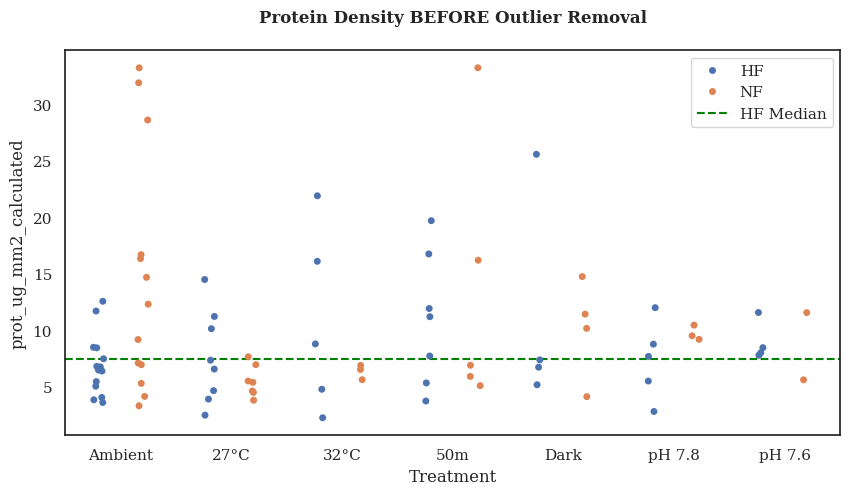

Sample counts per group BEFORE cleaning:


morph,HF,NF
Treatment,,
27°C,8,7
32°C,5,3
50m,7,5
Ambient,14,13
Dark,4,4
pH 7.6,4,2
pH 7.8,5,3


In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

# Let's look at the distribution of HF values before cleaning to see why they were flagged
df_before = df_prot.dropna(subset=['prot_ug_mm2_calculated']).copy()

plt.figure(figsize=(10, 5))
sns.stripplot(data=df_before, x='Treatment', y='prot_ug_mm2_calculated', hue='morph', dodge=True)
plt.title('Protein Density BEFORE Outlier Removal')
plt.axhline(df_before[df_before['morph']=='HF']['prot_ug_mm2_calculated'].median(), color='green', linestyle='--', label='HF Median')
plt.legend()
plt.show()

# Count samples per group before cleaning
print("Sample counts per group BEFORE cleaning:")
display(df_before.groupby(['Treatment', 'morph']).size().unstack())


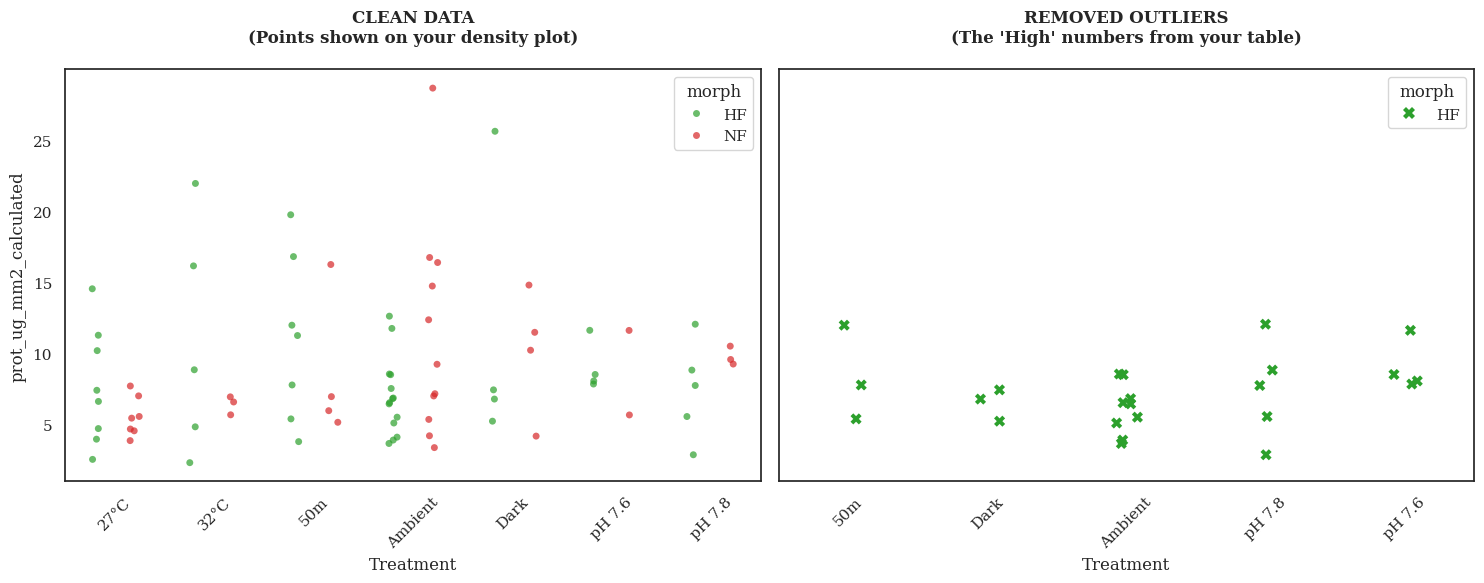

The maximum value in your 'Clean' plot is: 28.67
The maximum value in your 'Removed' table is: 12.06


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a comparison plot to show Clean vs Removed data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Plot 1: The Final Cleaned Data (What is in your density plot)
sns.stripplot(data=df_clean, x='Treatment', y='prot_ug_mm2_calculated', hue='morph',
              dodge=True, ax=ax1, palette=variant_colors, alpha=0.7)
ax1.set_title("CLEAN DATA\n(Points shown on your density plot)")
ax1.tick_params(axis='x', rotation=45)

# Plot 2: The Removed Outliers
if not removed_outliers.empty:
    sns.stripplot(data=removed_outliers, x='Treatment', y='prot_ug_mm2_calculated', hue='morph',
                  dodge=True, ax=ax2, palette=variant_colors, marker='X', size=8)
    ax2.set_title("REMOVED OUTLIERS\n(The 'High' numbers from your table)")
    ax2.tick_params(axis='x', rotation=45)
else:
    ax2.text(0.5, 0.5, "No Outliers Removed", ha='center')

plt.tight_layout()
plt.show()

print(f"The maximum value in your 'Clean' plot is: {df_clean['prot_ug_mm2_calculated'].max():.2f}")
print(f"The maximum value in your 'Removed' table is: {removed_outliers['prot_ug_mm2_calculated'].max():.2f}")

# Block 5: Normality Checks and Statistical Testing
Loops through every experimental treatment. It runs the Shapiro-Wilk test on both HF and NF groups to check if the variance is "normal". If both pass ($p>0.05$), it runs a parametric Welch's T-test. If either fails, it assigns a non-parametric Mann-Whitney U test. It saves the $p$-values for plotting.

In [44]:
import pandas as pd
from scipy import stats

all_treatments = ["Ambient", "27°C", "32°C", "pH 7.8", "pH 7.6", "50m", "Dark"]
stats_results = {}

print("✅ Final Statistical Results (Full Dataset, No Outlier Removal):")
print("-" * 105)
print(f"{'Condition':<15} | {'N (HF/NF)':<12} | {'Test Used':<18} | {'p-value':<10} | {'Significance'}")
print("-" * 105)

for cond in all_treatments:
    cond_data = df_clean[df_clean['Treatment'] == cond]
    hf = cond_data[cond_data['morph'] == 'HF']['prot_ug_mm2_calculated'].dropna()
    nf = cond_data[cond_data['morph'] == 'NF']['prot_ug_mm2_calculated'].dropna()
    n_hf, n_nf = len(hf), len(nf)
    n_str = f"{n_hf}/{n_nf}"

    if n_hf >= 3 and n_nf >= 2:
        _, p_sh = stats.shapiro(hf) if n_hf >= 3 else (0, 1.0)
        _, p_sn = stats.shapiro(nf) if n_nf >= 3 else (0, 1.0)
        if p_sh > 0.05 and p_sn > 0.05:
            test_used, (_, p_val) = "Welch's t-test", stats.ttest_ind(hf, nf, equal_var=False)
        else:
            test_used, (_, p_val) = "Mann-Whitney U", stats.mannwhitneyu(hf, nf, alternative='two-sided')
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
        stats_results[cond] = {'p_val': p_val, 'sig': sig}
        print(f"{cond:<15} | {n_str:<12} | {test_used:<18} | {p_val:<10.4f} | {sig}")
    else:
        print(f"{cond:<15} | {n_str:<12} | Insufficient Data   | N/A        | -")

✅ Final Statistical Results (Full Dataset, No Outlier Removal):
---------------------------------------------------------------------------------------------------------
Condition       | N (HF/NF)    | Test Used          | p-value    | Significance
---------------------------------------------------------------------------------------------------------
Ambient         | 14/13        | Mann-Whitney U     | 0.0392     | *
27°C            | 8/7          | Welch's t-test     | 0.2027     | ns
32°C            | 5/3          | Welch's t-test     | 0.2920     | ns
pH 7.8          | 5/3          | Welch's t-test     | 0.2036     | ns
pH 7.6          | 4/2          | Welch's t-test     | 0.9224     | ns
50m             | 7/5          | Welch's t-test     | 0.6748     | ns
Dark            | 4/4          | Mann-Whitney U     | 0.8857     | ns


# Block 6: Generating the Master Plot
 Renders  high-impact, publication-ready boxplot. It overlays the jittered raw data points and automatically draws the * or  significance markers directly above the treatments where the statistical tests found differences.

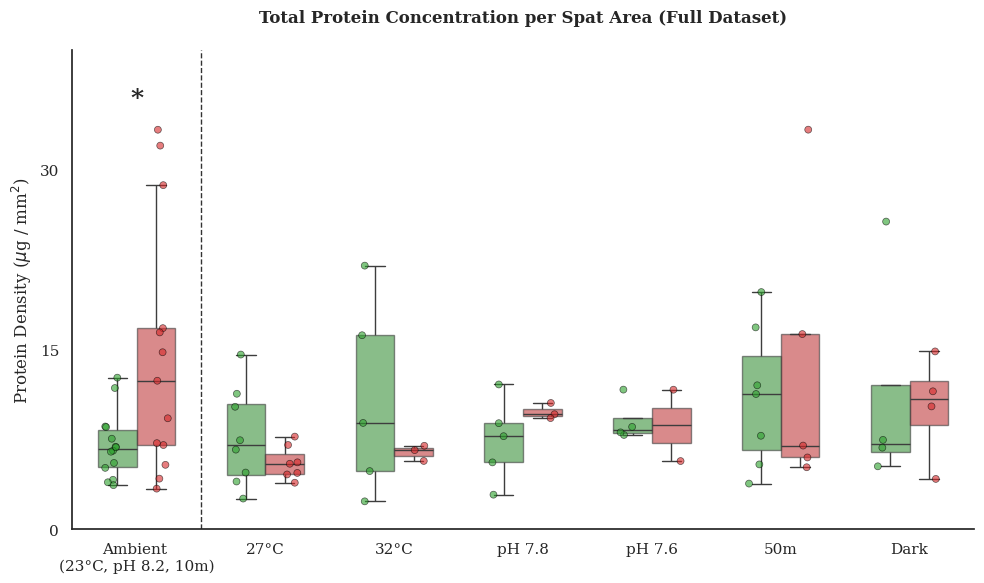

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

fig, ax = plt.subplots(figsize=global_fig_size)
display_map = {'Ambient': 'Ambient \n(23°C, pH 8.2, 10m)', '27°C': '27°C', '32°C': '32°C', 'pH 7.8': 'pH 7.8', 'pH 7.6': 'pH 7.6', '50m': '50m', 'Dark': 'Dark'}

plot_df = df_clean.copy()
plot_df['Display_Treatment'] = plot_df['Treatment'].map(display_map)

sns.boxplot(data=plot_df, x='Display_Treatment', y='prot_ug_mm2_calculated', hue='morph', order=sub_condition_plot_order, hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, width=0.6, boxprops=dict(alpha=0.6), showfliers=False)
sns.stripplot(data=plot_df, x='Display_Treatment', y='prot_ug_mm2_calculated', hue='morph', order=sub_condition_plot_order, hue_order=['HF', 'NF'], palette=variant_colors, ax=ax, dodge=True, size=global_marker_size, alpha=global_alpha, jitter=global_jitter, edgecolor='black', linewidth=0.5)

ax.axvline(x=0.5, color='black', linestyle='--', linewidth=1, alpha=0.8)
y_max = plot_df['prot_ug_mm2_calculated'].max()

for i, display_name in enumerate(sub_condition_plot_order):
    internal_name = next((k for k, v in display_map.items() if v == display_name), None)
    if internal_name in stats_results:
        sig_text = stats_results[internal_name]['sig']
        if sig_text != 'ns':
            ax.text(i, y_max * 1.05, sig_text, ha='center', va='bottom', fontsize=global_asterisk_size, fontweight=global_asterisk_weight)

ax.set_title('Total Protein Concentration per Spat Area (Full Dataset)', fontweight='bold')
ax.set_ylabel(r'Protein Density ($\mu$g / mm$^{2}$)')
ax.set_xlabel('')
ax.yaxis.set_major_locator(MaxNLocator(nbins=global_y_nbins))
ax.set_ylim(0, y_max * 1.2)
if ax.get_legend(): ax.get_legend().remove()
sns.despine()
plt.tight_layout()
plt.show()